In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tools
import os
from tqdm import tqdm

# Labels and image shape

In [19]:
labels_set = set()
image_shapes = set()
for file in tqdm(os.listdir('data/train/')):
    path = f'data/train/{file}'
    _, images, metadata, labels = tools.open_file(path)
    for i, l in enumerate(labels):
        labels_set.add(int(l))
        image_shapes.add(images[i].shape)


  8%|▊         | 81/1000 [00:12<02:20,  6.54it/s]


KeyboardInterrupt: 

In [ ]:
labels_set, image_shapes

({0, 1}, {(3, 96, 96)})

In [8]:
labels_set = set()
image_shapes = set()
for file in tqdm(os.listdir('data/val/')):
    path = f'data/val/{file}'
    _, images, metadata, labels = tools.open_file(path)
    for i, l in enumerate(labels):
        labels_set.add(int(l))
        image_shapes.add(images[i].shape)

100%|██████████| 1000/1000 [00:59<00:00, 16.76it/s]


In [9]:
labels_set, image_shapes

({0, 1}, {(3, 96, 96)})

In [10]:
image_shapes = set()
for file in tqdm(os.listdir('data/test/')):
    path = f'data/test/{file}'
    _, images, metadata, labels = tools.open_file(path)
    for i, l in enumerate(labels):
        image_shapes.add(images[i].shape)

100%|██████████| 1000/1000 [01:49<00:00,  9.13it/s]


In [11]:
labels_set, image_shapes

({0, 1}, {(3, 96, 96)})

# Number of samples and positives by centers

In [12]:
#Nb of samples, positives by center
# Keys are centers' ids
nb_samples_train = {0: 0, 3: 0, 4: 0}
nb_positives_train = {0: 0, 3: 0, 4: 0}
for file in tqdm(os.listdir('data/train/')):
    path = f'data/train/{file}'
    _, images, metadata, labels = tools.open_file(path)
    for i, m in enumerate(metadata):
        nb_samples_train[m[0]] += 1
        nb_positives_train[m[0]] += labels[i]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [02:26<00:00,  6.83it/s]


In [13]:
np.array(list(nb_positives_train.values())) / np.array(list(nb_samples_train.values()))

array([0.5035481 , 0.50219321, 0.50165563])

In [14]:
nb_samples_train, np.array(list(nb_samples_train.values())).sum()

({0: 17756, 3: 38756, 4: 43488}, np.int64(100000))

In [15]:
#Nb of samples, positives by center
#Key is center's id
nb_samples_val = {1: 0}
nb_positives_val = {1: 0}
for file in tqdm(os.listdir('data/val/')):
    path = f'data/val/{file}'
    _, images, metadata, labels = tools.open_file(path)
    for i, m in enumerate(metadata):
        nb_samples_val[m[0]] += 1
        nb_positives_val[m[0]] += labels[i]

100%|██████████| 1000/1000 [01:03<00:00, 15.78it/s]


In [16]:
nb_samples_val

{1: 34904}

In [17]:
np.array(list(nb_positives_val.values())) / np.array(list(nb_samples_val.values()))

array([0.5])

In [18]:
nb_samples_test = 0
for file in tqdm(os.listdir('data/test/')):
    path = f'data/test/{file}'
    _, images, metadata, labels = tools.open_file(path)
    nb_samples_test += len(images)

  0%|          | 0/1000 [00:00<?, ?it/s]

  8%|▊         | 83/1000 [00:13<02:23,  6.37it/s]


KeyboardInterrupt: 

In [ ]:
nb_samples_test

85054

## Check the intensity distribution for the different datasets and the centers 

In [41]:
import h5py
intensity_per_center = {0: [], 3: [], 4: []}
TRAIN_IMAGES_PATH = '../data_test/train.h5'
with h5py.File(TRAIN_IMAGES_PATH, 'r') as hdf:
   for img_idx in list(hdf.keys()):
            label = int(np.array(hdf.get(img_idx).get('label')))
            center = int(np.array(hdf.get(img_idx).get('metadata'))[0])
            image = np.array(hdf.get(img_idx).get('img'))
            print(image)
            intensiy_per_center[center].append(np.mean(image))

[[[0.906  0.953  0.9414 ... 0.9805 0.9766 0.9727]
  [0.902  0.9253 0.9214 ... 0.9766 0.9766 0.9766]
  [0.9097 0.937  0.929  ... 0.9727 0.9766 0.9766]
  ...
  [0.996  0.9414 0.961  ... 0.9844 0.9805 0.9766]
  [0.9805 0.9883 0.992  ... 0.9844 0.9805 0.9766]
  [0.961  0.992  0.9727 ... 0.9805 0.9766 0.9766]]

 [[0.7646 0.816  0.8394 ... 0.9766 0.9766 0.9766]
  [0.796  0.816  0.816  ... 0.9727 0.9727 0.9727]
  [0.784  0.8315 0.8315 ... 0.9688 0.9688 0.9688]
  ...
  [0.992  0.9453 0.9414 ... 0.9805 0.9844 0.9844]
  [0.9766 0.992  0.965  ... 0.9805 0.9844 0.9844]
  [0.961  0.992  0.953  ... 0.9805 0.9844 0.9844]]

 [[0.847  0.863  0.886  ... 0.9727 0.9727 0.9688]
  [0.863  0.855  0.863  ... 0.9688 0.9688 0.9688]
  [0.8354 0.8706 0.886  ... 0.965  0.9688 0.9688]
  ...
  [0.9805 0.965  0.965  ... 0.9805 0.9805 0.9844]
  [0.9844 0.9844 0.9844 ... 0.9727 0.9766 0.9766]
  [0.9727 0.965  0.961  ... 0.9727 0.9727 0.9688]]]
[[[0.9883 0.9883 0.9844 ... 0.992  0.992  0.9883]
  [0.9883 0.9883 0.9844 ..

KeyboardInterrupt: 

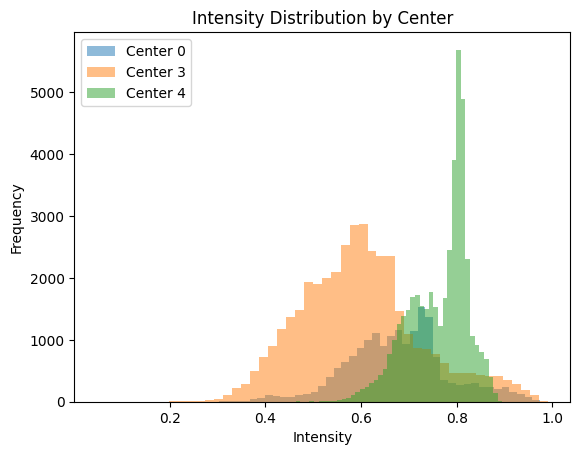

In [36]:
for center_id, intensities in intensiy_per_center.items():
    plt.hist(intensities, bins=50, alpha=0.5, label=f'Center {center_id}')

plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Intensity Distribution by Center')
plt.legend()
plt.show()